# Analisis de inventario

Analisis del dataset Kaggle_Dataset.csv para stock y riesgo de rotura.

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [30]:
PATH_DATASET_STOCK = '../data/raw/Kaggle_Dataset.csv'
df_stock = pd.read_csv(PATH_DATASET_STOCK, parse_dates=['Date'])
df_stock.columns = df_stock.columns.str.lower()
print(f'Filas: {len(df_stock):,} | Columnas: {df_stock.shape[1]}')
print(f"Periodo: {df_stock['date'].min().date()} a {df_stock['date'].max().date()}")
df_stock.head()

Filas: 200,000 | Columnas: 41
Periodo: 2023-01-01 a 2025-12-30


,product_id,product_category,brand,sku,current_stock,reorder_level,safety_stock,inventory_turnover,supplier_id,supplier_rating,...,month,quarter,year,demand_forecast,inventory_optimization_score,supplier_performance_score,supply_chain_efficiency,sustainability_score,predicted_reorder_quantity,operational_risk_score
0,PRD0000001,Fashion,BrandD,SKU191221,660,146,317,16.13,SUP1114,2.81,...,7,3,2025,6859,13.00,62.03,35.34,19.86,3949,3.99
1,PRD0000002,Home,BrandB,SKU116795,1681,176,219,1.11,SUP2811,2.77,...,9,3,2025,438,98.14,53.57,56.87,61.67,3820,39.96
2,PRD0000003,Electronics,BrandC,SKU344678,8195,714,109,8.38,SUP0815,5.00,...,4,2,2025,7961,17.37,6.47,87.55,35.81,1899,87.99
3,PRD0000004,Food,BrandC,SKU674236,4312,320,155,3.19,SUP0201,1.57,...,12,4,2023,19091,30.86,76.55,27.23,36.13,1288,70.06
4,PRD0000005,Fashion,BrandA,SKU327399,4067,981,222,5.85,SUP3354,1.53,...,6,2,2023,18036,31.06,19.25,20.44,92.92,4278,9.15


## Calidad y exploracion

In [31]:
df_stock.info()
display(df_stock.describe(include='all').transpose())
print('Duplicados:', df_stock.duplicated().sum())
display(df_stock.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   product_id                    200000 non-null  str           
 1   product_category              200000 non-null  str           
 2   brand                         200000 non-null  str           
 3   sku                           200000 non-null  str           
 4   current_stock                 200000 non-null  int64         
 5   reorder_level                 200000 non-null  int64         
 6   safety_stock                  200000 non-null  int64         
 7   inventory_turnover            200000 non-null  float64       
 8   supplier_id                   200000 non-null  str           
 9   supplier_rating               200000 non-null  float64       
 10  lead_time_days                200000 non-null  int64         
 11  warehouse_id            

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,200000,200000,PRD0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,200000,5,Food,40240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,200000,4,BrandD,50159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,200000,179325,SKU947212,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_stock,200000.0,NaN,NaN,NaN,5001.1209,0.0,2495.0,5000.0,7507.0,9999.0,2891.173975
reorder_level,200000.0,NaN,NaN,NaN,505.412565,10.0,257.0,507.0,754.0,999.0,286.002597
safety_stock,200000.0,NaN,NaN,NaN,254.18908,10.0,131.0,254.0,376.0,499.0,141.454268
inventory_turnover,200000.0,NaN,NaN,NaN,10.017377,0.0,5.01,10.04,15.02,20.0,5.780697
supplier_id,200000,4999,SUP1964,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_rating,200000.0,NaN,NaN,NaN,3.000134,1.0,2.0,3.0,4.0,5.0,1.152276


Duplicados: 0


product_id            0
product_category      0
brand                 0
sku                   0
current_stock         0
reorder_level         0
safety_stock          0
inventory_turnover    0
supplier_id           0
supplier_rating       0
dtype: int64

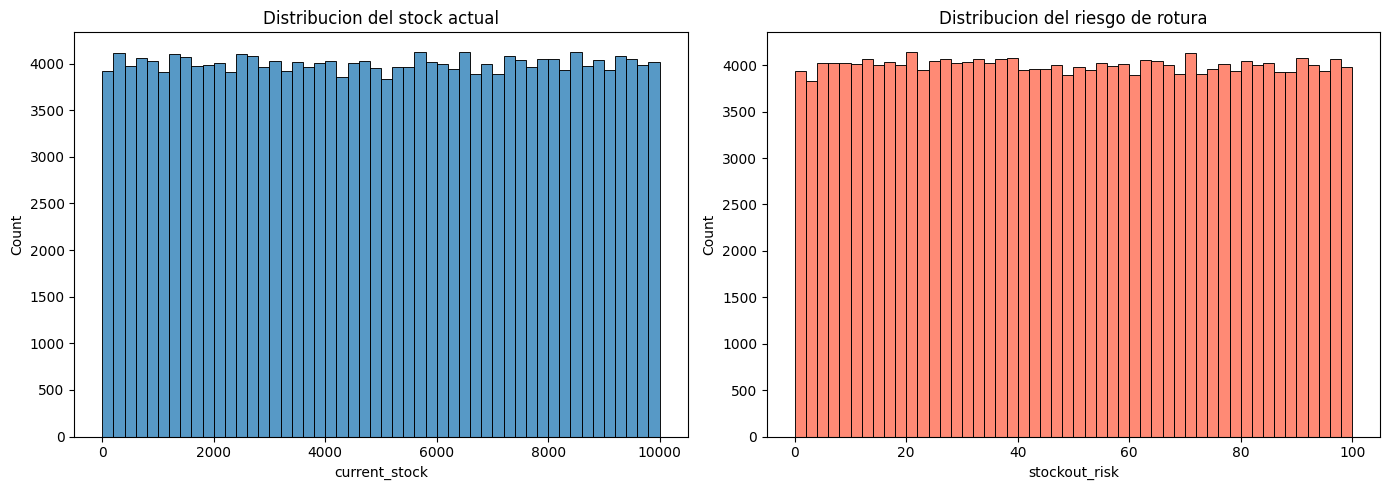

In [32]:
sample_stock = df_stock.sample(n=min(3000, len(df_stock)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_stock, x='current_stock', bins=50, ax=axes[0])
axes[0].set_title('Distribucion del stock actual')
sns.histplot(data=df_stock, x='stockout_risk', bins=50, color='tomato', ax=axes[1])
axes[1].set_title('Distribucion del riesgo de rotura')
plt.tight_layout()

In [33]:
display(df_stock.groupby('product_category', observed=True)['stockout_risk'].agg(['mean','median','count']).sort_values('mean', ascending=False))
display(df_stock.groupby('month', observed=True)['stockout_risk'].mean())
for col in ['product_category', 'warehouse_location', 'transportation_mode']:
    print(f'--- {col} ---')
    print(df_stock[col].value_counts())

,mean,median,count
product_category,,,
Health,50.056768,49.90,39877
Food,50.049503,50.02,40240
Home,49.914202,50.05,40145
Electronics,49.876676,49.82,39688
Fashion,49.823881,49.67,40050


month
1     50.168822
2     49.887879
3     49.798972
4     49.733777
5     50.113830
6     49.946839
7     49.744708
8     50.289581
9     49.991949
10    49.666238
11    49.885928
12    50.091327
Name: stockout_risk, dtype: float64

--- product_category ---
product_category
Food           40240
Home           40145
Fashion        40050
Health         39877
Electronics    39688
Name: count, dtype: int64
--- warehouse_location ---
warehouse_location
North    50093
East     50051
South    49963
West     49893
Name: count, dtype: int64
--- transportation_mode ---
transportation_mode
Sea     50144
Road    50110
Air     49972
Rail    49774
Name: count, dtype: int64


stockout_risk                   1.000000
shipping_cost_usd               0.005495
on_time_delivery_rate           0.004914
revenue_usd                     0.004121
year                            0.003753
monthly_demand                  0.003161
supply_disruption_risk          0.002941
storage_capacity                0.002758
daily_demand                    0.002261
operational_risk_score          0.001689
supplier_performance_score      0.001672
reorder_level                   0.001575
demand_forecast                 0.001494
lead_time_days                  0.001479
supply_chain_efficiency         0.001461
predicted_reorder_quantity      0.001348
product_cost_usd                0.000579
units_sold                      0.000578
seasonal_demand_index           0.000315
current_stock                   0.000254
selling_price_usd               0.000201
safety_stock                    0.000148
month                          -0.000124
sustainability_score           -0.000342
quarter         

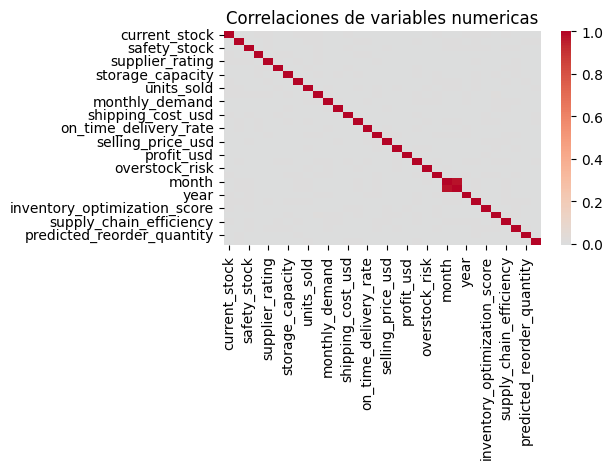

In [34]:
corr_matrix = df_stock.select_dtypes(include='number').corr()
display(corr_matrix['stockout_risk'].sort_values(ascending=False))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlaciones de variables numericas')
plt.tight_layout()

## Modelo predictivo de stockout_risk

In [35]:
target = 'stockout_risk'
features = ['product_category','brand','current_stock','reorder_level','safety_stock','inventory_turnover','supplier_rating','lead_time_days','warehouse_location','utilization_rate','units_sold','daily_demand','monthly_demand','seasonal_demand_index','shipping_cost_usd','transportation_mode','delivery_time_days','on_time_delivery_rate','demand_forecast','supply_disruption_risk']
X = pd.get_dummies(df_stock[features], columns=['product_category','brand','warehouse_location','transportation_mode'], drop_first=True)
y = df_stock[target]
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True)).fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = {'Linear Regression': LinearRegression(), 'Random Forest': RandomForestRegressor(n_estimators=80, max_depth=12, random_state=42, n_jobs=-1)}
results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({'Modelo': name, 'RMSE': np.sqrt(mean_squared_error(y_test, pred)), 'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)})
results = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results)

,Modelo,RMSE,MAE,R2
0,Linear Regression,28.760739,24.881926,-0.000120
1,Random Forest,28.770435,24.887531,-0.000795


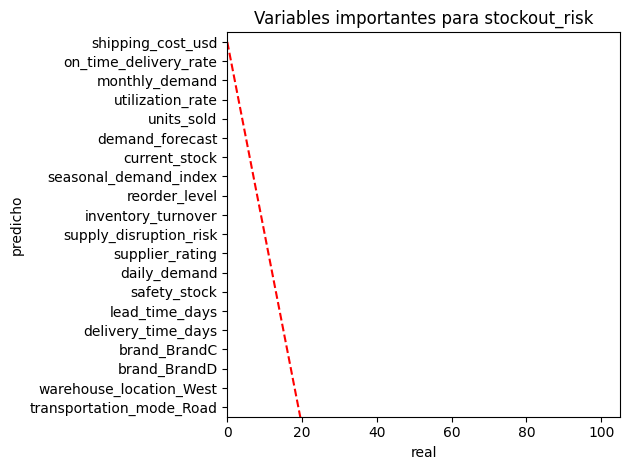

In [36]:
comparison = pd.DataFrame({'real': y_test, 'predicho': predictions['Random Forest']})
sns.scatterplot(data=comparison.sample(n=min(3000, len(comparison)), random_state=42), x='real', y='predicho', alpha=0.35)
plt.plot([0, 100], [0, 100], 'r--')
plt.title('Riesgo real frente a predicho')
plt.tight_layout()
importance = pd.DataFrame({'feature': X_train.columns, 'importance': models['Random Forest'].feature_importances_}).sort_values('importance', ascending=False)
sns.barplot(data=importance.head(20), x='importance', y='feature')
plt.title('Variables importantes para stockout_risk')
plt.tight_layout()